In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
df_table = pd.read_csv("MBH_table_final.csv")

In [7]:
df_table.head()

,Galaxy,M_BH,M_BH_lower,M_BH_upper,sigma,Morph,Method,Source,Paper reference,MASSIVE?,BCG?,Limits source (for filled rows only)
0,A1836,3900000000,3300000000,4300000000,288.0,E,gas,MM13,NaN,NaN,NaN,NaN
1,A3565,1400000000,1200000000,1700000000,322.0,E,gas,MM13,NaN,NaN,NaN,NaN
2,CIRC,1700000,1400000,2100000,158.0,S,maser,MM13,NaN,NaN,NaN,NaN
3,IC1459,2800000000,1600000000,3900000000,315.0,E,star,MM13,NaN,NaN,NaN,NaN
4,MW,4100000,3500000,4700000,103.0,S,star,MM13,NaN,NaN,NaN,NaN


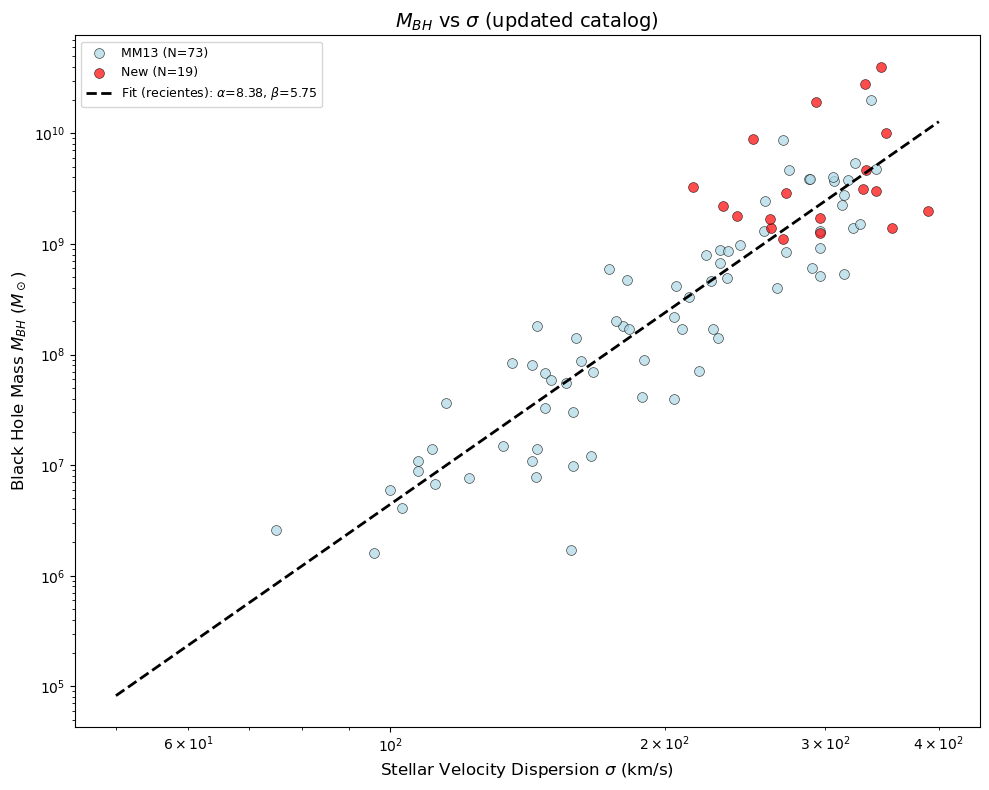

Fit con galaxias recientes (N=92):
  alpha = 8.376
  beta  = 5.747


In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)", fontsize=12)
ax.set_ylabel("Black Hole Mass $M_{BH}$ ($M_\odot$)", fontsize=12)
ax.set_title("$M_{BH}$ vs $\sigma$ (updated catalog)", fontsize=14)

# Grupo 1: MM13 + MM13_updated (las que ya estaban en MM13, actualizadas o no)
mask_mm13 = df_table["Source"].isin(["MM13", "MM13_updated"])
sub_mm13 = df_table[mask_mm13]
ax.scatter(sub_mm13["sigma"], sub_mm13["M_BH"],
           color="lightblue", s=50, alpha=0.7,
           edgecolors="black", linewidths=0.5,
           label=f"MM13 (N={len(sub_mm13)})")

# Grupo 2: New
mask_new = df_table["Source"] == "New"
sub_new = df_table[mask_new]
ax.scatter(sub_new["sigma"], sub_new["M_BH"],
           color="red", s=50, alpha=0.7,
           edgecolors="black", linewidths=0.5,
           label=f"New (N={len(sub_new)})")
        

logx = np.log10(df_table["sigma"] / 200.0)
logy = np.log10(df_table["M_BH"])
beta, alpha = np.polyfit(logx, logy, 1)

# Dibujar línea del fit
sigma_grid = np.linspace(50, 400, 200)
x_grid = np.log10(sigma_grid / 200.0)
y_fit = alpha + beta * x_grid
ax.plot(sigma_grid, 10**y_fit, "k--", linewidth=2,
        label=f"Fit (recientes): $\\alpha$={alpha:.2f}, $\\beta$={beta:.2f}")

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Fit con galaxias recientes (N={len(df_table)}):")
print(f"  alpha = {alpha:.3f}")
print(f"  beta  = {beta:.3f}")
